In [1]:
# ==========================================================
# TITANIC SURVIVAL PREDICTION PROJECT
#
# Author      : Pooja Oswal
# Dataset     : Titanic Dataset (Kaggle)
# Language    : Python
#
# Description :
# This project predicts passenger survival on the Titanic
# using Machine Learning. It includes data preprocessing,
# feature engineering, exploratory data analysis (EDA),
# model training, evaluation, and prediction.
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

TITANIC SURVIVAL PREDICTION

 Dataset Loaded Successfully

========== FIRST FIVE ROWS ==========
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0   

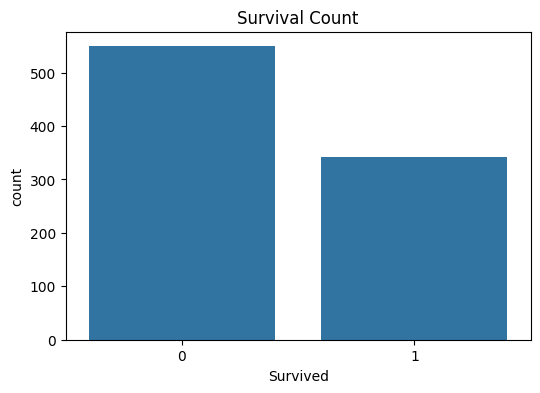

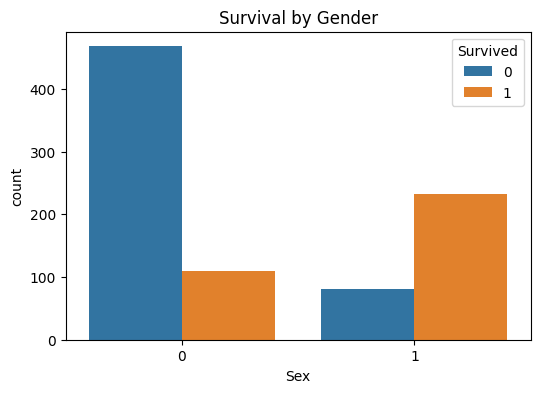

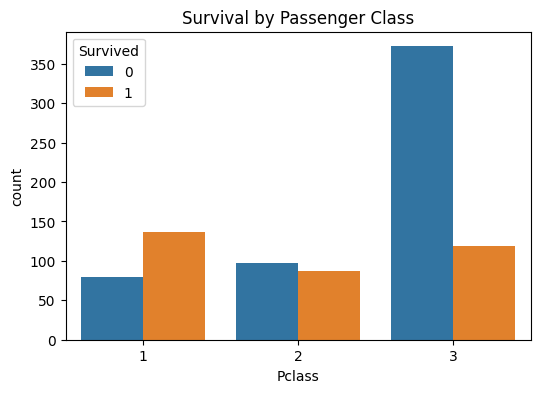

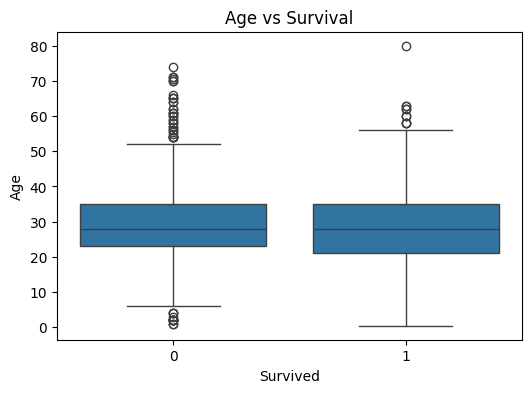

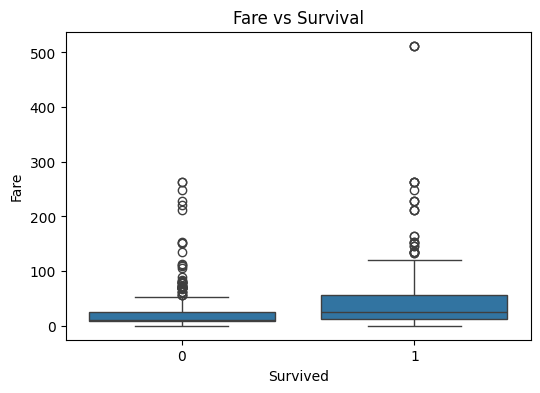

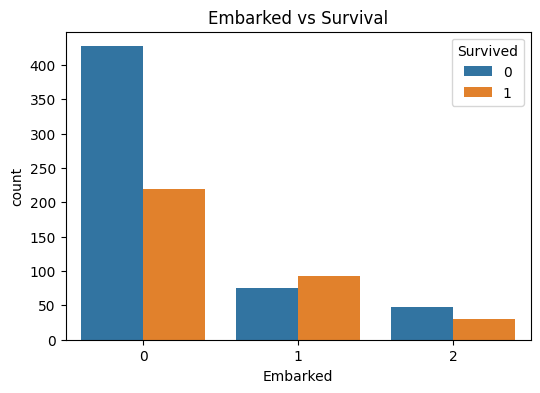

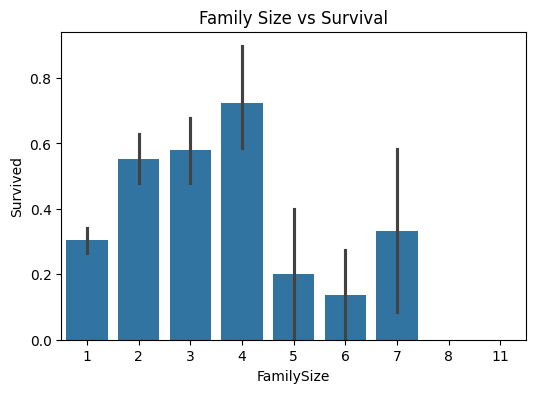

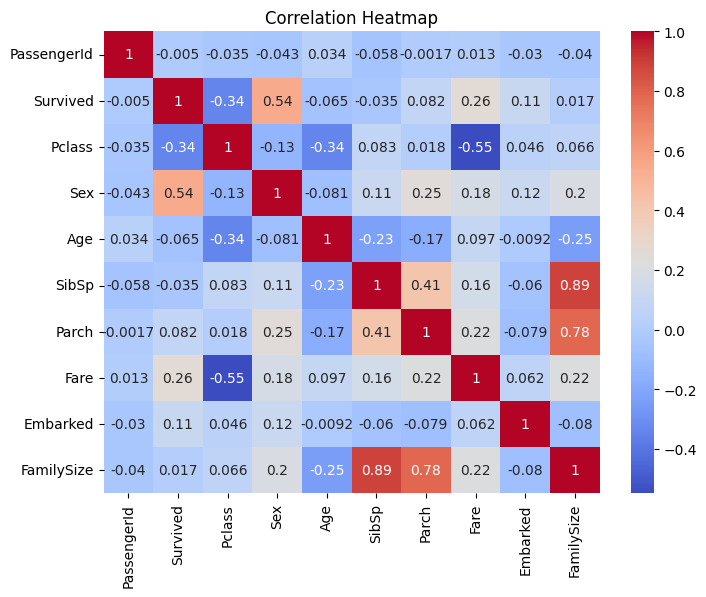


MACHINE LEARNING MODEL

Features Shape : (891, 8)
Target Shape : (891,)

Training Data : (712, 8)
Testing Data : (179, 8)

 Model Trained Successfully

Accuracy : 79.89 %

Confusion Matrix
[[89 16]
 [20 54]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


 Model Saved Successfully

BUSINESS INSIGHTS

1. Overall Survival Rate : 38.38%
2. Female Survival Rate : 74.20%
3. Male Survival Rate : 18.89%
4. First Class Survival Rate : 62.96%
5. Second Class Survival Rate : 47.28%
6. Third Class Survival Rate : 24.24%
7. Total Passengers : 891
8. Average Passenger Age : 29.36 years
9. Average Ticket Fare : 32.20
10. Average Family Size : 1.90

 Titanic Survival Prediction Project Completed Succes

In [5]:
def main():

    print("=" * 70)
    print("TITANIC SURVIVAL PREDICTION")
    print("=" * 70)

    # ---------------------------------------------------------
    # Load Dataset
    # ---------------------------------------------------------

    df = pd.read_csv("Titanic-Dataset.csv")

    print("\n Dataset Loaded Successfully")

    # ---------------------------------------------------------
    # First Five Rows
    # ---------------------------------------------------------

    print("\n========== FIRST FIVE ROWS ==========")
    print(df.head())

    # ---------------------------------------------------------
    # Last Five Rows
    # ---------------------------------------------------------

    print("\n========== LAST FIVE ROWS ==========")
    print(df.tail())

    # ---------------------------------------------------------
    # Dataset Shape
    # ---------------------------------------------------------

    print("\n========== DATASET SHAPE ==========")
    print(df.shape)

    # ---------------------------------------------------------
    # Column Names
    # ---------------------------------------------------------

    print("\n========== COLUMN NAMES ==========")
    print(df.columns)

    # ---------------------------------------------------------
    # Data Types
    # ---------------------------------------------------------

    print("\n========== DATA TYPES ==========")
    print(df.dtypes)

    # ---------------------------------------------------------
    # Dataset Information
    # ---------------------------------------------------------

    print("\n========== DATASET INFO ==========")
    df.info()

    # ---------------------------------------------------------
    # Statistical Summary
    # ---------------------------------------------------------

    print("\n========== STATISTICAL SUMMARY ==========")
    print(df.describe(include="all"))

    # ---------------------------------------------------------
    # Missing Values
    # ---------------------------------------------------------

    print("\n========== MISSING VALUES ==========")
    print(df.isnull().sum())
        # ---------------------------------------------------------
    # Handle Missing Values
    # ---------------------------------------------------------

    print("\n========== DATA CLEANING ==========")

    # Drop Cabin column (too many missing values)
    print("\nDropping 'Cabin' column...")
    df.drop("Cabin", axis=1, inplace=True)

    # Fill missing Age values with median
    print("Filling missing values in 'Age'...")
    df["Age"] = df["Age"].fillna(df["Age"].median())

    # Fill missing Embarked values with mode
    print("Filling missing values in 'Embarked'...")
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # Check Missing Values Again
    print("\n========== MISSING VALUES AFTER CLEANING ==========")
    print(df.isnull().sum())

    # ---------------------------------------------------------
    # Check Duplicate Rows
    # ---------------------------------------------------------

    duplicates = df.duplicated().sum()

    print("\nDuplicate Rows Before Cleaning :", duplicates)

    if duplicates > 0:

        df.drop_duplicates(inplace=True)

        print(" Duplicate Rows Removed")

    else:

        print(" No Duplicate Rows Found")

    print("Duplicate Rows After Cleaning :", df.duplicated().sum())

    # ---------------------------------------------------------
    # Feature Engineering
    # ---------------------------------------------------------

    print("\n========== FEATURE ENGINEERING ==========")

    # Create Family Size feature
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    print(" FamilySize feature created.")

    # ---------------------------------------------------------
    # Encode Categorical Columns
    # ---------------------------------------------------------

    print("\nEncoding categorical columns...")

    # Encode Sex
    df["Sex"] = df["Sex"].map({
        "male": 0,
        "female": 1
    })

    # Encode Embarked
    df["Embarked"] = df["Embarked"].map({
        "S": 0,
        "C": 1,
        "Q": 2
    })

    print(" Encoding Completed.")

    # ---------------------------------------------------------
    # Final Dataset
    # ---------------------------------------------------------

    print("\n========== FINAL DATASET ==========")

    print("Shape :", df.shape)

    print("\nFirst Five Rows")

    print(df.head())

    print("\n Data Cleaning Completed Successfully!")
        # ==========================================================
    # EXPLORATORY DATA ANALYSIS (EDA)
    # ==========================================================

    print("\n" + "="*70)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*70)

    import os

    if not os.path.exists("images"):
        os.makedirs("images")

    # ---------------------------------------------------------
    # Graph 1 : Survival Count
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.countplot(x="Survived", data=df)

    plt.title("Survival Count")
    plt.savefig("images/survival_count.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 2 : Survival by Gender
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.countplot(x="Sex", hue="Survived", data=df)

    plt.title("Survival by Gender")
    plt.savefig("images/survival_by_gender.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 3 : Survival by Passenger Class
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.countplot(x="Pclass", hue="Survived", data=df)

    plt.title("Survival by Passenger Class")
    plt.savefig("images/survival_by_class.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 4 : Age vs Survival
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Survived", y="Age", data=df)

    plt.title("Age vs Survival")
    plt.savefig("images/age_vs_survival.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 5 : Fare vs Survival
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.boxplot(x="Survived", y="Fare", data=df)

    plt.title("Fare vs Survival")
    plt.savefig("images/fare_vs_survival.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 6 : Embarked vs Survival
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.countplot(x="Embarked", hue="Survived", data=df)

    plt.title("Embarked vs Survival")
    plt.savefig("images/embarked_vs_survival.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 7 : Family Size vs Survival
    # ---------------------------------------------------------

    plt.figure(figsize=(6,4))
    sns.barplot(x="FamilySize", y="Survived", data=df)

    plt.title("Family Size vs Survival")
    plt.savefig("images/familysize_vs_survival.png")
    plt.show()


    # ---------------------------------------------------------
    # Graph 8 : Correlation Heatmap
    # ---------------------------------------------------------

    plt.figure(figsize=(8,6))

    sns.heatmap(
        df.corr(numeric_only=True),
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Correlation Heatmap")
    plt.savefig("images/correlation_heatmap.png")
    plt.show()
        # ==========================================================
    # MACHINE LEARNING
    # ==========================================================

    print("\n" + "="*70)
    print("MACHINE LEARNING MODEL")
    print("="*70)

    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

    # ---------------------------------------------------------
    # Feature Selection
    # ---------------------------------------------------------

    X = df.drop(["PassengerId", "Name", "Ticket", "Survived"], axis=1)
    y = df["Survived"]

    print("\nFeatures Shape :", X.shape)
    print("Target Shape :", y.shape)

    # ---------------------------------------------------------
    # Train Test Split
    # ---------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print("\nTraining Data :", X_train.shape)
    print("Testing Data :", X_test.shape)

    # ---------------------------------------------------------
    # Train Model
    # ---------------------------------------------------------

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train, y_train)

    print("\n Model Trained Successfully")

    # ---------------------------------------------------------
    # Prediction
    # ---------------------------------------------------------

    y_pred = model.predict(X_test)

    # ---------------------------------------------------------
    # Accuracy
    # ---------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    print("\nAccuracy :", round(accuracy * 100, 2), "%")

    # ---------------------------------------------------------
    # Confusion Matrix
    # ---------------------------------------------------------

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test, y_pred))

    # ---------------------------------------------------------
    # Classification Report
    # ---------------------------------------------------------

    print("\nClassification Report")

    print(classification_report(y_test, y_pred))
        # ==========================================================
    # SAVE MODEL
    # ==========================================================

    import joblib

    joblib.dump(model, " titanic_model.pkl")

    print("\n Model Saved Successfully")


    # ==========================================================
    # BUSINESS INSIGHTS
    # ==========================================================

    print("\n" + "="*70)
    print("BUSINESS INSIGHTS")
    print("="*70)

    survival_rate = (df["Survived"].mean()) * 100

    female_survival = (
        df[df["Sex"] == 1]["Survived"].mean()
    ) * 100

    male_survival = (
        df[df["Sex"] == 0]["Survived"].mean()
    ) * 100

    first_class = (
        df[df["Pclass"] == 1]["Survived"].mean()
    ) * 100

    second_class = (
        df[df["Pclass"] == 2]["Survived"].mean()
    ) * 100

    third_class = (
        df[df["Pclass"] == 3]["Survived"].mean()
    ) * 100

    print(f"\n1. Overall Survival Rate : {survival_rate:.2f}%")

    print(f"2. Female Survival Rate : {female_survival:.2f}%")

    print(f"3. Male Survival Rate : {male_survival:.2f}%")

    print(f"4. First Class Survival Rate : {first_class:.2f}%")

    print(f"5. Second Class Survival Rate : {second_class:.2f}%")

    print(f"6. Third Class Survival Rate : {third_class:.2f}%")

    print(f"7. Total Passengers : {len(df)}")

    print(f"8. Average Passenger Age : {df['Age'].mean():.2f} years")

    print(f"9. Average Ticket Fare : {df['Fare'].mean():.2f}")

    print(f"10. Average Family Size : {df['FamilySize'].mean():.2f}")

    print("\n Titanic Survival Prediction Project Completed Successfully!")

    return df
df = main()
